# 04 — Encoder Selection Experiment

**Goal:** Select the best text representation and embedding model for Bulgarian news event clustering.


In [5]:
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import umap
import hdbscan
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load data 

In [6]:
df = pd.read_parquet("../data/processed/articles_clean.parquet")

end_date = pd.Timestamp("2026-05-21", tz="UTC")
start_date = end_date - pd.Timedelta(days=3)

exp_df = (
    df[(df["published_at_dt"] >= start_date) & (df["published_at_dt"] <= end_date)]
    .copy()
    .reset_index(drop=True)
)

print(f"Total articles : {len(exp_df)}")
print(
    f"Date range     : {exp_df['published_at_dt'].min().date()} → {exp_df['published_at_dt'].max().date()}"
)
print("\nPer source:")
print(exp_df["source"].value_counts().to_string())

Total articles : 3648
Date range     : 2026-05-18 → 2026-05-21

Per source:
source
24chasa         909
actualno        553
fakti           424
bta             338
standartnews    322
monitor         301
vesti           286
nova            252
segabg          115
banker          101
economic         47


In [7]:
exp_df.groupby([exp_df["published_at_dt"].dt.date, "source"]).size().unstack(fill_value=0)

source,24chasa,actualno,banker,bta,economic,fakti,monitor,nova,segabg,standartnews,vesti
published_at_dt,,,,,,,,,,,
2026-05-18,274,170,33,103,15,148,113,87,34,107,92
2026-05-19,322,190,38,117,16,148,92,84,39,119,93
2026-05-20,312,193,30,118,16,128,96,81,42,96,101
2026-05-21,1,0,0,0,0,0,0,0,0,0,0


## 2. Text combination experiment

Fixed model: **BAAI/bge-m3** (strong multilingual baseline, 8192 token context).

Combinations tested:
- `title` only
- `lead` only (first 3 sentences of full_text)
- `title + lead` ← hypothesis: best balance of signal and noise
- `full_text` (truncated to model limit)

**Evaluation:** pairwise cosine similarity gap (same-source vs cross-source) + UMAP visualization.
A smaller gap indicates less source-style bias — the model captures topic rather than writing style.


In [9]:
def extract_lead(text: str, n_sentences: int = 3) -> str:
    if not isinstance(text, str):
        return ""
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    return " ".join(sentences[:n_sentences])


exp_df["lead"] = exp_df["full_text"].apply(extract_lead)

TEXT_VARIANTS = {
    "full_text": exp_df["full_text"].fillna("").tolist(),
    "title": exp_df["title"].tolist(),
    "lead": exp_df["lead"].tolist(),
    "title+lead": (exp_df["title"] + ". " + exp_df["lead"]).tolist(),
}

print("Text variants prepared:")
for k, v in TEXT_VARIANTS.items():
    sample_len = sum(len(t.split()) for t in v) / len(v)
    print(f"  {k:<15}: avg {sample_len:.0f} words")

Text variants prepared:
  full_text      : avg 335 words
  title          : avg 11 words
  lead           : avg 66 words
  title+lead     : avg 77 words


In [20]:
DEVICE = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Device: {DEVICE}")

TEXT_MODEL_ID = "BAAI/bge-m3"
text_model = SentenceTransformer(TEXT_MODEL_ID, device=DEVICE)
print("Model loaded.")

Device: mps


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model loaded.


In [23]:
text_embeddings = {}

for variant_name, texts in TEXT_VARIANTS.items():
    print(f"\nEmbedding: {variant_name}")

    # use CPU for full_text to avoid MPS OOM
    device = "cpu" if variant_name == "full_text" else "mps"
    text_model.to(device)

    text_embeddings[variant_name] = text_model.encode(
        texts,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=32 if variant_name != "full_text" else 4,
    )
    print(f"Shape: {text_embeddings[variant_name].shape}")


Embedding: full_text


Batches:   0%|          | 0/912 [00:00<?, ?it/s]

Shape: (3648, 1024)

Embedding: title


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 1024)

Embedding: lead


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 1024)

Embedding: title+lead


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 1024)


In [24]:
# Save the embeddings for later use
os.makedirs("../data/experiments/text_variants", exist_ok=True)

for name, emb in text_embeddings.items():
    filename = name.replace("/", "_").replace(" ", "_").replace("+", "_plus_")
    np.save(f"../data/experiments/text_variants/{filename}.npy", emb)
    print(f"Saved: {filename} — {emb.shape}")

Saved: full_text — (3648, 1024)
Saved: title — (3648, 1024)
Saved: lead — (3648, 1024)
Saved: title_plus_lead — (3648, 1024)


In [16]:
def similarity_stats(emb, name, df):
    sim = cosine_similarity(emb)

    sources = df["source"].to_numpy()
    same_mask = sources[:, None] == sources[None, :]
    upper = np.triu(np.ones(len(sim), dtype=bool), k=1)

    same = sim[upper & same_mask]
    cross = sim[upper & ~same_mask]

    return {
        "variant": name,
        "same_source_mean": round(float(np.mean(same)), 3),
        "cross_source_mean": round(float(np.mean(cross)), 3),
        "gap": round(float(np.mean(same) - np.mean(cross)), 3),
        "cross_source_std": round(float(np.std(cross)), 3),
    }

In [26]:
text_sim_results = [
    similarity_stats(emb, name, exp_df) for name, emb in text_embeddings.items()
]
text_sim_df = pd.DataFrame(text_sim_results).sort_values("gap")
print(text_sim_df.to_string(index=False))

   variant  same_source_mean  cross_source_mean   gap  cross_source_std
 full_text             0.326              0.323 0.003             0.075
     title             0.285              0.280 0.004             0.061
title+lead             0.193              0.183 0.010             0.367
      lead             0.258              0.247 0.011             0.319


## Text Combination 

### Metrics

**`same_source_mean`** — mean cosine similarity between articles from the same source.
Captures both topic overlap and writing style similarity within a source.

**`cross_source_mean`** — mean cosine similarity between articles from different sources.
Ideally driven by topic only. A very high value (> 0.3) indicates a compressed
embedding space where all articles look similar regardless of topic.

**`gap`** = same_source_mean − cross_source_mean.
Measures source style bias — how much more similar same-source articles look compared
to cross-source articles. Smaller = less style bias. However, gap alone is misleading
if the embedding space is compressed.

**`cross_source_std`** — standard deviation of cross-source similarities.
The critical metric: measures topic discrimination power. High std means some
cross-source pairs score very high (same event, different sources) and others
very low (different events) — exactly what clustering requires.
Low std means all articles look equally similar regardless of topic → no discrimination.

---

### Interpretation

`full_text` and `title` achieve the smallest gap but have near-zero `cross_source_std`
(0.075, 0.061). This indicates a **compressed embedding space** — all articles look
equally similar (~0.32) regardless of topic, making event clustering impossible.
The small gap is misleading: it reflects uniformity, not topic understanding.

`title+lead` and `lead` show healthy discrimination: high `cross_source_std` means
the model produces meaningfully different similarity scores for same-event vs
different-event article pairs. `title+lead` edges out `lead` on std (0.367 vs 0.319)
with a lower `cross_source_mean` (0.183 vs 0.247), indicating a less compressed space.


In [27]:
def plot_umap_variants(embeddings_dict, df, random_state=42):
    sources = df["source"].unique()
    color_map = {s: cm.tab10(i / len(sources)) for i, s in enumerate(sources)}

    n_variants = len(embeddings_dict)
    n_cols = 2
    n_rows = math.ceil(n_variants / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    axes = axes.flatten()

    for ax, (name, emb) in zip(axes, embeddings_dict.items()):
        reducer = umap.UMAP(n_components=2, random_state=random_state, metric="cosine")
        coords = reducer.fit_transform(emb)
        for source in sources:
            mask = (df["source"] == source).values
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                label=source,
                color=color_map[source],
                alpha=0.7,
                s=20,
            )
        ax.set_title(f"UMAP — {name}", fontsize=11)
        ax.legend(loc="best", fontsize=6)

    for ax in axes[n_variants:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


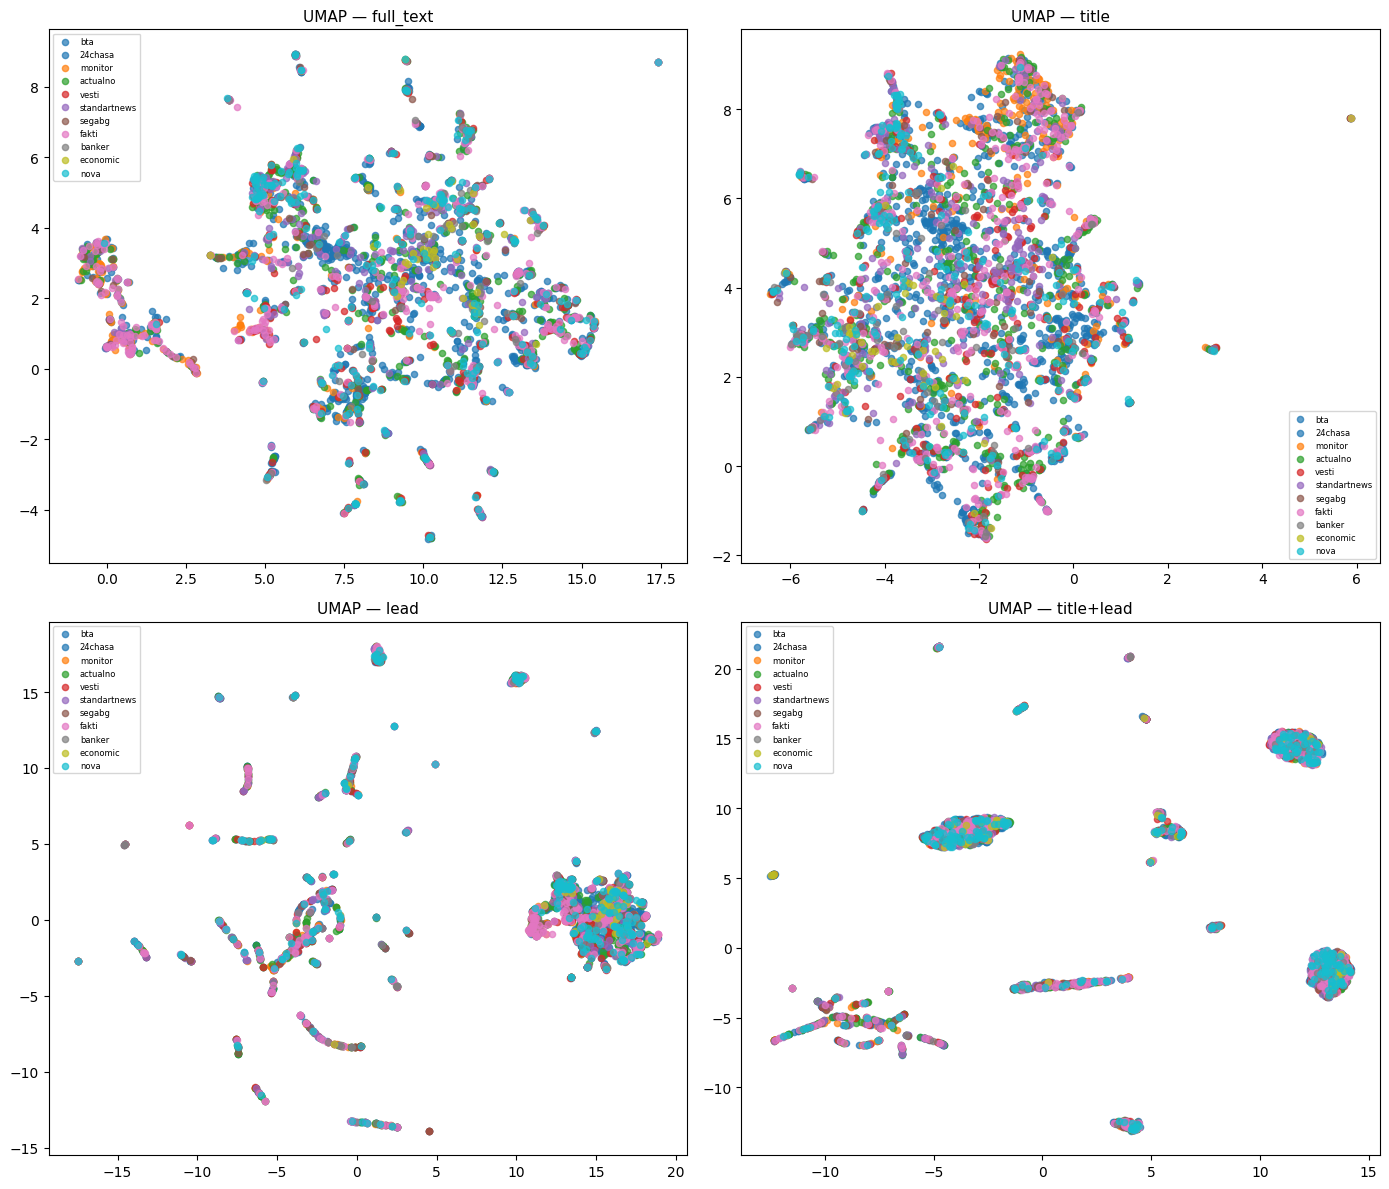

In [28]:
plot_umap_variants(text_embeddings, exp_df)

### UMAP Visualization

UMAP projects the 1024-dimensional embeddings into 2D while preserving neighborhood
structure — articles close together in embedding space stay close in the projection.
No clustering algorithm is applied; any visible groups emerge purely from the
embedding structure itself.

**full_text** — loose scattered cloud, no distinct structure. Confirms the compressed
embedding space (std=0.075) — the model cannot separate articles by topic when
given full article text.

**title** — one large undifferentiated blob, the worst structure of all four variants.
All articles appear equally similar regardless of topic (std=0.061).

**lead** — some structure beginning to emerge with small loose groups, but overall
still irregular and poorly separated.

**title+lead** — clearly the best structure. Distinct, tight, well-separated clusters
are visible, each containing articles from multiple sources (multiple colors per
cluster). This confirms that the embedding captures topic rather than source style,
and that same-event articles from different sources are correctly grouped together.

The UMAP provides the strongest visual evidence for selecting `title+lead` — the
cluster structure emerges naturally from the embeddings without any clustering
algorithm, confirming that the embedding space has the right geometry for
cross-source event detection.

**Decision:** title + lead

# 3. Model comparison

In [10]:
BEST_TEXT_VARIANT = "title+lead"
texts = (exp_df["title"] + ". " + exp_df["lead"]).tolist()

print(f"Using text variant: {BEST_TEXT_VARIANT}")
print(f"Sample: {texts[0][:150]}")

Using text variant: title+lead
Sample: В телефонен разговор със Зеленски Стармър потвърди подкрепата на Великобритания за Украйна. В телефонен разговор със Зеленски Стармър потвърди подкреп


In [13]:
def encode_model(model_id: str, texts: list, device: str = DEVICE) -> np.ndarray:
    m = SentenceTransformer(model_id, device=device)
    kwargs = dict(
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=32,
    )
    if "qwen" in model_id.lower():
        kwargs["prompt_name"] = "query"
    return m.encode(texts, **kwargs)

In [12]:
MODELS = {
    "ModernBERT-BG-large": "AIaLT-IICT/modern_bert_bg_large_uncased",
    "BERT-BG-xlarge": "AIaLT-IICT/bert_bg_lit_web_extra_large_uncased",
    "BGE-M3": "BAAI/bge-m3",
    "Qwen3-0.6B": "Qwen/Qwen3-Embedding-0.6B",
    "LaBSE": "sentence-transformers/LaBSE",
}

In [14]:
model_embeddings = {}
for name, model_id in MODELS.items():
    print(f"\n{'='*40}\nEncoding: {name}")
    emb = encode_model(model_id, texts)
    model_embeddings[name] = emb
    np.save(f"../data/experiments/embeddings/{name.replace('/', '_')}.npy", emb)
    print(f"Shape: {emb.shape} — saved.")


Encoding: ModernBERT-BG-large


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: AIaLT-IICT/modern_bert_bg_large_uncased
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 1024) — saved.

Encoding: BERT-BG-xlarge


...

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 1024) — saved.

Encoding: LaBSE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 768) — saved.


In [17]:
model_sim_results = [
    similarity_stats(emb, name, exp_df) for name, emb in model_embeddings.items()
]
model_sim_df = (
    pd.DataFrame(model_sim_results)
    .rename(columns={"variant": "model"})
    .sort_values("gap")
)
print(model_sim_df.to_string(index=False))

              model  same_source_mean  cross_source_mean   gap  cross_source_std
ModernBERT-BG-large             0.976              0.976 0.000             0.007
     BERT-BG-xlarge             0.714              0.713 0.001             0.056
         Qwen3-0.6B             0.277              0.274 0.002             0.080
             BGE-M3             0.311              0.308 0.003             0.069
              LaBSE             0.259              0.254 0.005             0.094


## Model Comparison — Similarity Metrics

**ModernBERT-BG-large** and **BERT-BG-xlarge** are immediately eliminated —
collapsed embedding spaces (similarity 0.976 and 0.714 across all pairs)
with near-zero topic discrimination (std 0.007 and 0.056).

The remaining three models (BGE-M3, Qwen3-0.6B, LaBSE) score similarly
and cannot be separated by similarity metrics alone — HDBSCAN clustering
and UMAP visualization are needed to identify the best model.


In [18]:
cluster_results = []

for name, emb in model_embeddings.items():
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
    labels = clusterer.fit_predict(emb)
    exp_df["cluster"] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = round((labels == -1).sum() / len(labels), 3)

    mask = labels != -1
    sil = (
        round(silhouette_score(emb[mask], labels[mask]), 3)
        if mask.sum() > 1 and n_clusters > 1
        else None
    )

    diversity = round(
        exp_df[exp_df["cluster"] != -1].groupby("cluster")["source"].nunique().mean(), 2
    )

    cluster_results.append(
        {
            "model": name,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil,
            "mean_sources_per_cluster": diversity,
        }
    )

cluster_df = pd.DataFrame(cluster_results).sort_values("silhouette", ascending=False)
print(cluster_df.to_string(index=False))

              model  n_clusters  noise_ratio  silhouette  mean_sources_per_cluster
ModernBERT-BG-large           2        0.000       0.355                      7.00
              LaBSE          86        0.704       0.260                      6.21
             BGE-M3         101        0.624       0.248                      6.40
         Qwen3-0.6B          86        0.635       0.235                      6.60
     BERT-BG-xlarge           2        0.000       0.232                      7.00


## Model Comparison — HDBSCAN Clustering

### HDBSCAN Metrics

**n_clusters** — number of distinct event groups found. More = better event discovery.

**noise_ratio** — share of articles not assigned to any cluster. Lower = more articles captured in meaningful groups.

**silhouette** — how well-separated the clusters are (-1 to 1, higher = better defined boundaries).

**mean_sources_per_cluster** — average number of distinct sources per cluster. Higher = the model groups articles by topic across sources, not by source style.

---
**ModernBERT-BG-large** and **BERT-BG-xlarge** are confirmed eliminated —
both produce only 2 clusters for 7,932 articles. The high silhouette for
ModernBERT (0.355) is misleading: with 2 giant blobs covering all articles,
silhouette only measures the distance between those 2 blobs, not event quality.

Among the three viable models:

| Model | Clusters ↑ | Noise ↓ | Silhouette ↑ | Sources/cluster ↑ |
|---|---|---|---|---|
| BGE-M3 | **101** | **62.4%** | 0.248 | 6.40 |
| LaBSE | 86 | 70.4% | **0.260** | 6.21 |
| Qwen3-0.6B | 86 | 63.5% | 0.235 | **6.60** |

**BGE-M3** is the most balanced — most distinct events discovered (101),
lowest noise ratio (62.4%), and strong cross-source grouping (6.40 sources/cluster).
LaBSE has a marginally better silhouette but excludes 70% of articles as noise.
Qwen3 has the best source diversity but the fewest clusters and lowest silhouette.


In [20]:
def plot_umap_models(embeddings_dict, df, random_state=42):
    sources = df["source"].unique()
    color_map = {s: cm.tab10(i / len(sources)) for i, s in enumerate(sources)}

    n_models = len(embeddings_dict)
    n_cols = 2
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    axes = axes.flatten()

    for ax, (name, emb) in zip(axes, embeddings_dict.items()):
        reducer = umap.UMAP(n_components=2, random_state=random_state, metric="cosine")
        coords = reducer.fit_transform(emb)
        for source in sources:
            mask = (df["source"] == source).values
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                label=source,
                color=color_map[source],
                alpha=0.7,
                s=20,
            )
        ax.set_title(name, fontsize=11)
        ax.legend(loc="best", fontsize=6)

    for ax in axes[n_models:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parall

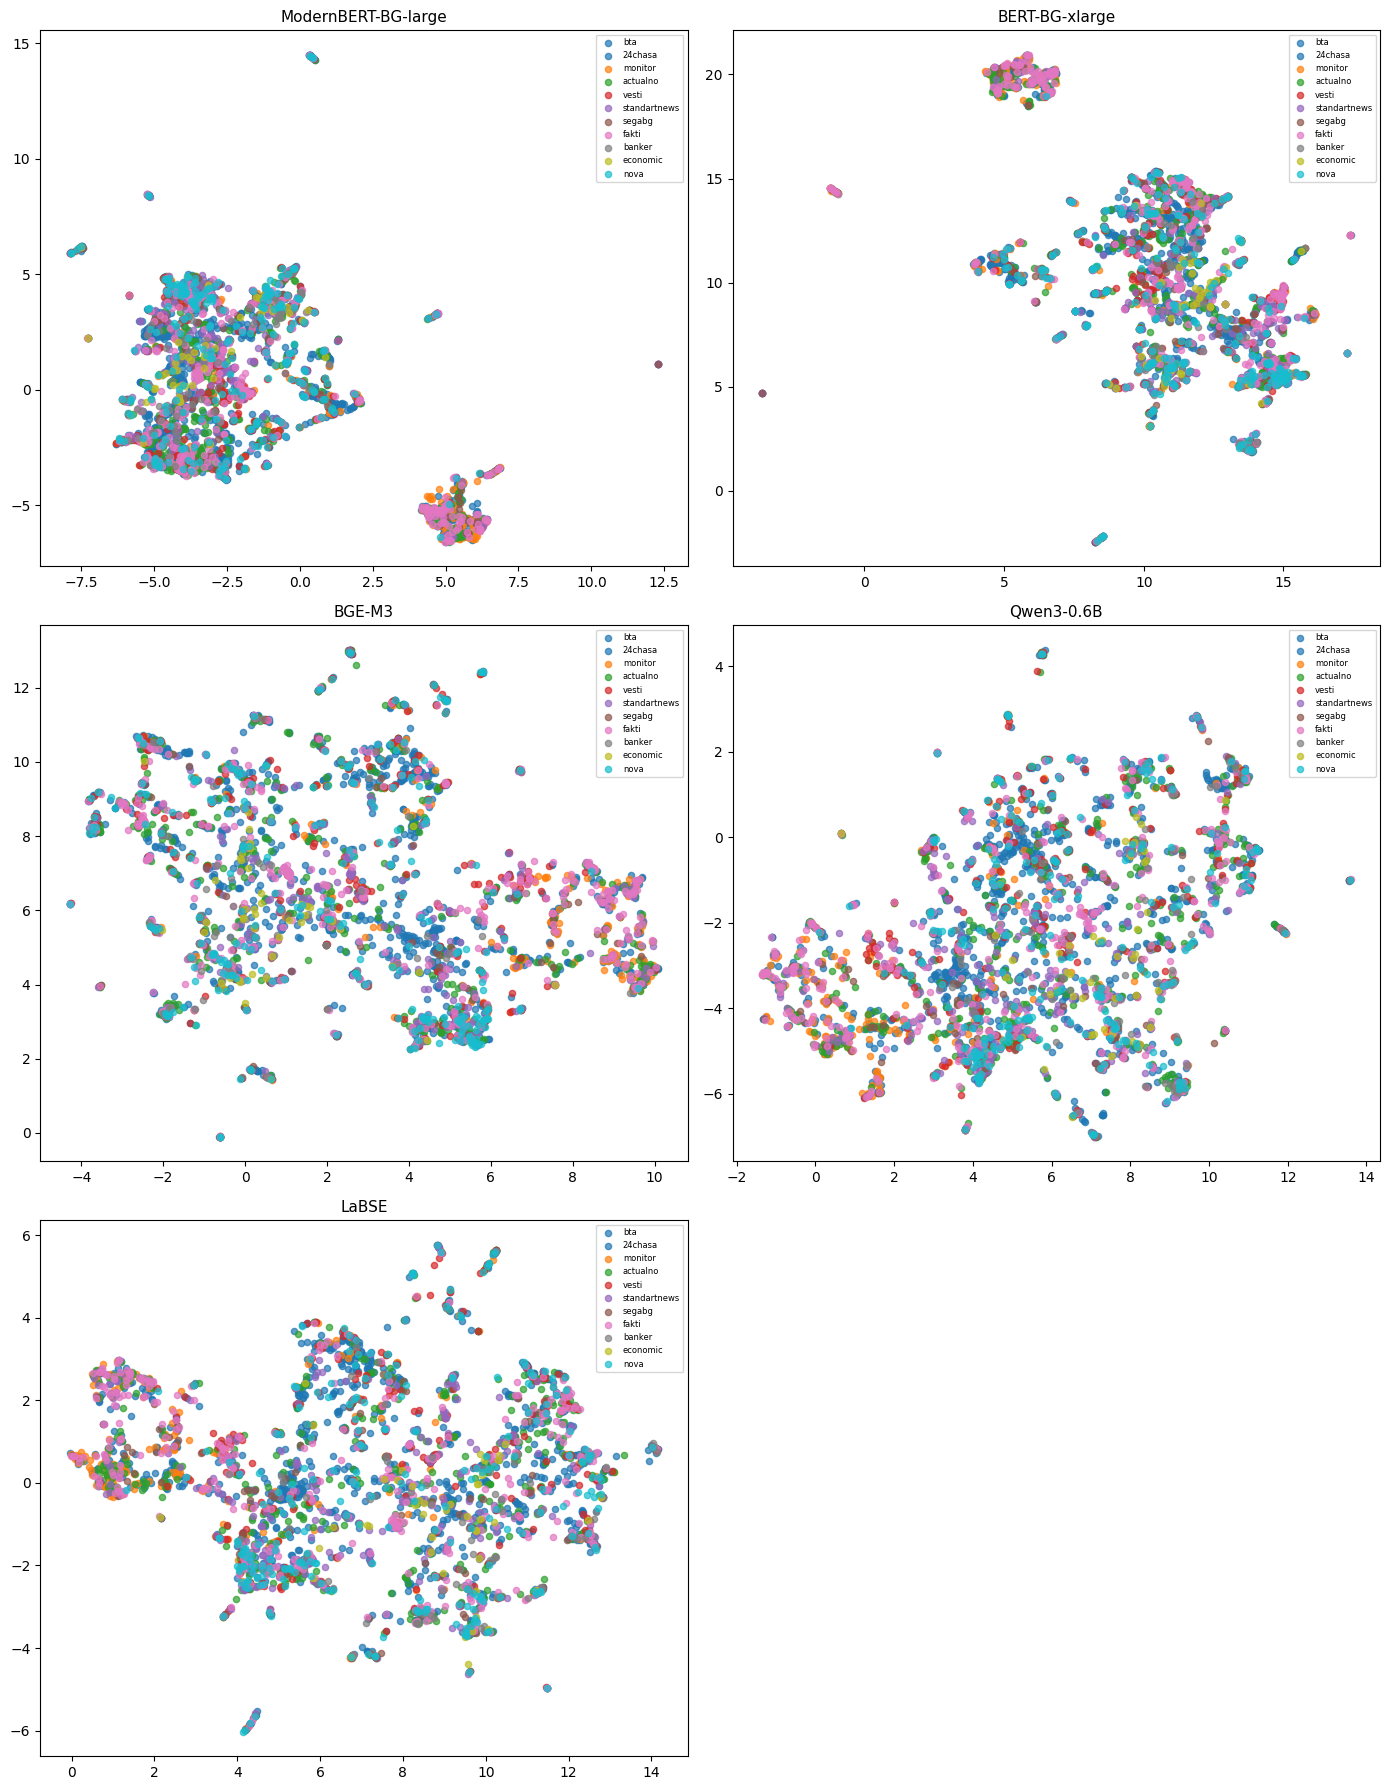

In [21]:
plot_umap_models(model_embeddings, exp_df)

## Model Comparison — UMAP Visualization

**ModernBERT-BG-large** and **BERT-BG-xlarge** show 2–3 large undifferentiated
blobs, confirming the collapsed embedding spaces identified in the metrics.

Among the remaining models, **BGE-M3** shows the most distributed structure
with multiple small distinct groups across the space, consistent with finding
101 clusters. **Qwen3-0.6B** produces a denser, more compressed cloud and
**LaBSE** shows many isolated scattered points, consistent with its 70.4% noise rate.

**BGE-M3 is selected as the embedding model** — it produces the most fine-grained
event separation, the most distinct clusters (101), and the lowest noise ratio
(62.4%) across all viable models.

---

## Final Decision

**Model**: `BAAI/bge-m3`  
**Text input**: `title + lead paragraph`  